# 强化学习中的探索与开采
在强化学习的世界里，智能体（Agent）就像一个在未知环境中不断学习、成长的探险家。它面临着一个贯穿始终的核心矛盾：是应该探索（Exploration） 未知领域，寻找可能带来更高回报的新路径，还是应该开采（Exploitation） 已知的最佳策略，稳定地获取当前已知的最大收益？这个"探索与开采的权衡"（Exploration-Exploitation Trade-off），是强化学习算法设计中最基本、最关键的挑战之一。理解并处理好这个矛盾，是智能体从新手成长为大师的必经之路。

-----

## 什么是探索与开采？

让我们先通过一个生活的比喻来理解这两个核心概念.

想象一下你在一个新的城市里寻找一家餐厅吃饭。你有两种选择：

- **开采(Exploitation)** : 你选择去你 **已知的 , 最喜欢的餐厅.** 你知道那里的菜符合你的口味 , 价格合适 , 服务质量稳定. 选择开采意味着你基于 **当前已知的最佳信息** 做出决策 , 目的是 **最大化当前的确定性收益**. 在强化学习中 , 这对应智能体选择当前估值(如Q值)最高的动作.
- **探索(Exploration)** : 你选择去你 **未知的 , 但听说不错的餐厅.** 你不知道那里的菜是否符合你的口味 , 价格如何 , 服务质量怎样. 选择探索意味着你 **为了获取更多关于环境的信息** 做出决策 , 目的是 **优化长期未来收益**. 在强化学习中 , 这对应智能体选择当前估值(如Q值)较低但具有潜在价值的动作.

强化学习智能体的目标，不是赢得某一次午餐，而是在**无数次午餐选择中，获得最大的长期满足感（累积奖励）**。如果只开采不探索，你可能永远发现不了那家更好的新餐馆，长期收益无法达到最优。如果只探索不开采，你可能会浪费大量时间和金钱在糟糕的餐馆上，无法享受已知的最佳选择。

----

## 为什么需要探索与开采的权衡？
探索与开采之所以需要权衡，根源在于环境的**不确定性**和智能体知识的**不完整性**。

- 1. 信息有限 : 智能体初始时对环境一无所知，它必须通过探索来收集数据，构建对世界（状态、动作、奖励、转移概率）的认知模型。
- 2. 机会成本 : 在探索和开采之间进行选择时，智能体需要考虑放弃的潜在收益。 选择开采可能错过更高回报的机会，选择探索可能错过当前已知的最佳回报。
- 3. 最优解的动态性 : 在非平稳环境中，最优策略可能会随时间变化。即使智能体找到了当前最优策略，也需要持续进行一定程度的探索，以适应环境变化，防止策略过时。
- 4. 学习效率 : 过度探索可能导致智能体在无用的状态空间中浪费资源，过度开采可能导致智能体陷入局部最优解。合理的权衡可以提高学习效率，加速收敛到全局最优策略。

----

## 常见的探索策略
如何在强化学习中实现探索与开采的权衡？以下是一些常见的策略：

### ε-贪婪策略 (ε-Greedy)
这是最简单也是最常用的探索策略之一。智能体以概率 ε 选择一个随机动作（探索），以概率 1-ε 选择当前估值最高的动作（开采）。通过调整 ε 的值，可以控制探索与开采的程度。通常，在训练初期设置较高的 ε 以促进探索，随着训练进展逐渐降低 ε 以增加开采。

In [22]:
import numpy as np

def epsilon_greedy(q_values, epsilon=0.3):
    """
    实现 ε-贪心策略
    Args:
        q_values: 一个数组，表示当前状态下每个动作的Q值估计。
        epsilon: 探索概率，介于0和1之间。
    Returns:
        selected_action: 根据策略选出的动作索引。
    """
    n_actions = len(q_values)
    
    # 以概率 epsilon 进行探索（随机选择）
    if np.random.random() < epsilon:
        selected_action = np.random.randint(n_actions)
    # 以概率 1-epsilon 进行开采（选择Q值最大的动作）
    else:
        # 如果多个动作Q值相同，随机选择一个
        selected_action = np.random.choice(np.where(q_values == np.max(q_values))[0])
    
    return selected_action

# 示例：假设在某个状态下，三个动作的Q值估计为 [1.5, 2.8, 2.3]
state_q_values = [1.5, 2.8, 2.3]
for i in range(10):
    action = epsilon_greedy(state_q_values, epsilon=0.2)
    print(f"第{i+1}次选择: 动作 {action} (Q值: {state_q_values[action]:.1f})")

第1次选择: 动作 2 (Q值: 2.3)
第2次选择: 动作 1 (Q值: 2.8)
第3次选择: 动作 1 (Q值: 2.8)
第4次选择: 动作 0 (Q值: 1.5)
第5次选择: 动作 1 (Q值: 2.8)
第6次选择: 动作 1 (Q值: 2.8)
第7次选择: 动作 1 (Q值: 2.8)
第8次选择: 动作 1 (Q值: 2.8)
第9次选择: 动作 1 (Q值: 2.8)
第10次选择: 动作 1 (Q值: 2.8)


### 上置信界策略 (Upper Confidence Bound, UCB)
UCB 策略通过为每个动作计算一个置信区间来平衡探索与开采。智能体选择具有最高上置信界的动作，这意味着它不仅考虑当前的估值，还考虑了动作的不确定性。UCB 鼓励智能体探索那些尚未充分尝试过的动作，从而提高长期收益。

它的核心思想是：为每个动作的估值加上一个"不确定性奖励"。一个动作被尝试的次数越少，其不确定性就越大，这个奖励项就越高，从而鼓励智能体去尝试它。

动作的公式如下：
$$a_t = \arg\max_a \left( Q(a) + c \sqrt{\frac{\ln t}{N_{t}(a)}} \right)$$
其中:
- Q(a) 是动作 a 的当前平均奖励估计(开采项)
- $N_{t}(a)$ 是时刻 t 为止动作 a 被选择的次数
- c 是一个平衡参数 , 控制探索与开采的权衡程度
- In t 是总时间步数的对数
- 根号项就是"不确定性奖励"或"探索奖励"。动作被选得越少（N_t(a) 小），这项的值就越大。
- $a_{t}$ 是智能体在时刻 t 选择的动作。

In [23]:
import numpy as np
import math

class UCB:
    def __init__(self , n_actions , c = 2):
        self.n_actions = n_actions
        self.c = c      # 探索参数
        self.Q = np.zeros(n_actions)  # 每个动作的平均奖励
        self.N = np.zeros(n_actions)  # 每个动作被选择的次数
        self.total_count = 0          # 总的选择次数

    def select_action(self):
        self.total_count += 1
        # 确保每个动作至少被选择一次
        if np.any(self.N == 0):
            action = np.random.choice(np.where(self.N == 0)[0])     # 随机选择一个未被选择过的动作
        else:
            # 计算每个动作的UCB值
            ucb_values = self.Q + self.c * np.sqrt(np.log(self.total_count) / self.N)
            action = np.argmax(ucb_values)  # 选择UCB值最大的动作
        return action
    
    def update(self, action, reward):
        # 更新动作的价值估计
        self.N[action] += 1
        # 增量式更新平均奖励 Q值 , NewEstimate = OldEstimate + (Reward - OldEstimate) / N[action]
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

# 模拟一个多臂老虎机问题 , 每个臂的真实奖励概率不同
true_means = [0.1 , 0.5 , 0.9]      # 三个臂的真实平均奖励
n_actions = len(true_means)
bandit = UCB(n_actions , c = 2)

total_reward = 0
for step in range(1000):
    action = bandit.select_action()  # 根据UCB策略选择动作
    # 模拟从选定的臂获得奖励（1表示成功，0表示失败）
    reward = 1 if np.random.random() < true_means[action] else 0
    bandit.update(action, reward)  # 更新UCB算法的内部状态
    total_reward += reward

print(f"Total reward: {total_reward}")  # 输出总奖励
print(f"Estimated Q-values: {bandit.Q}")    # 输出每个动作的估计Q值
print(f"Action selection counts: {bandit.N}")   # 输出每个动作被选择的次数

Total reward: 841
Estimated Q-values: [0.12903226 0.48780488 0.89853439]
Action selection counts: [ 31.  82. 887.]


优点 : UCB 策略能够自适应地调整探索与开采的平衡，随着时间的推移，智能体会逐渐减少对已知动作的探索，更多地利用当前的最佳策略。能够更快的收敛到最优策略，特别是在动作空间较大时。
缺点 : UCB 策略需要维护每个动作的选择次数和平均奖励估计，可能会增加计算和存储的复杂度。在某些环境中，过度探索可能导致性能下降。

### 汤姆森采样 (Thompson Sampling)
这是一种基于贝叶斯思想的概率性方法。智能体为每个动作的奖励分布（例如伯努利分布的参数 θ_a）维护一个先验分布（如 Beta 分布）。每一步，智能体从每个动作的后验分布中采样一个可能的奖励参数 θ_a，然后选择采样值最大的那个动作执行。收到真实奖励后，再根据结果更新该动作的后验分布。

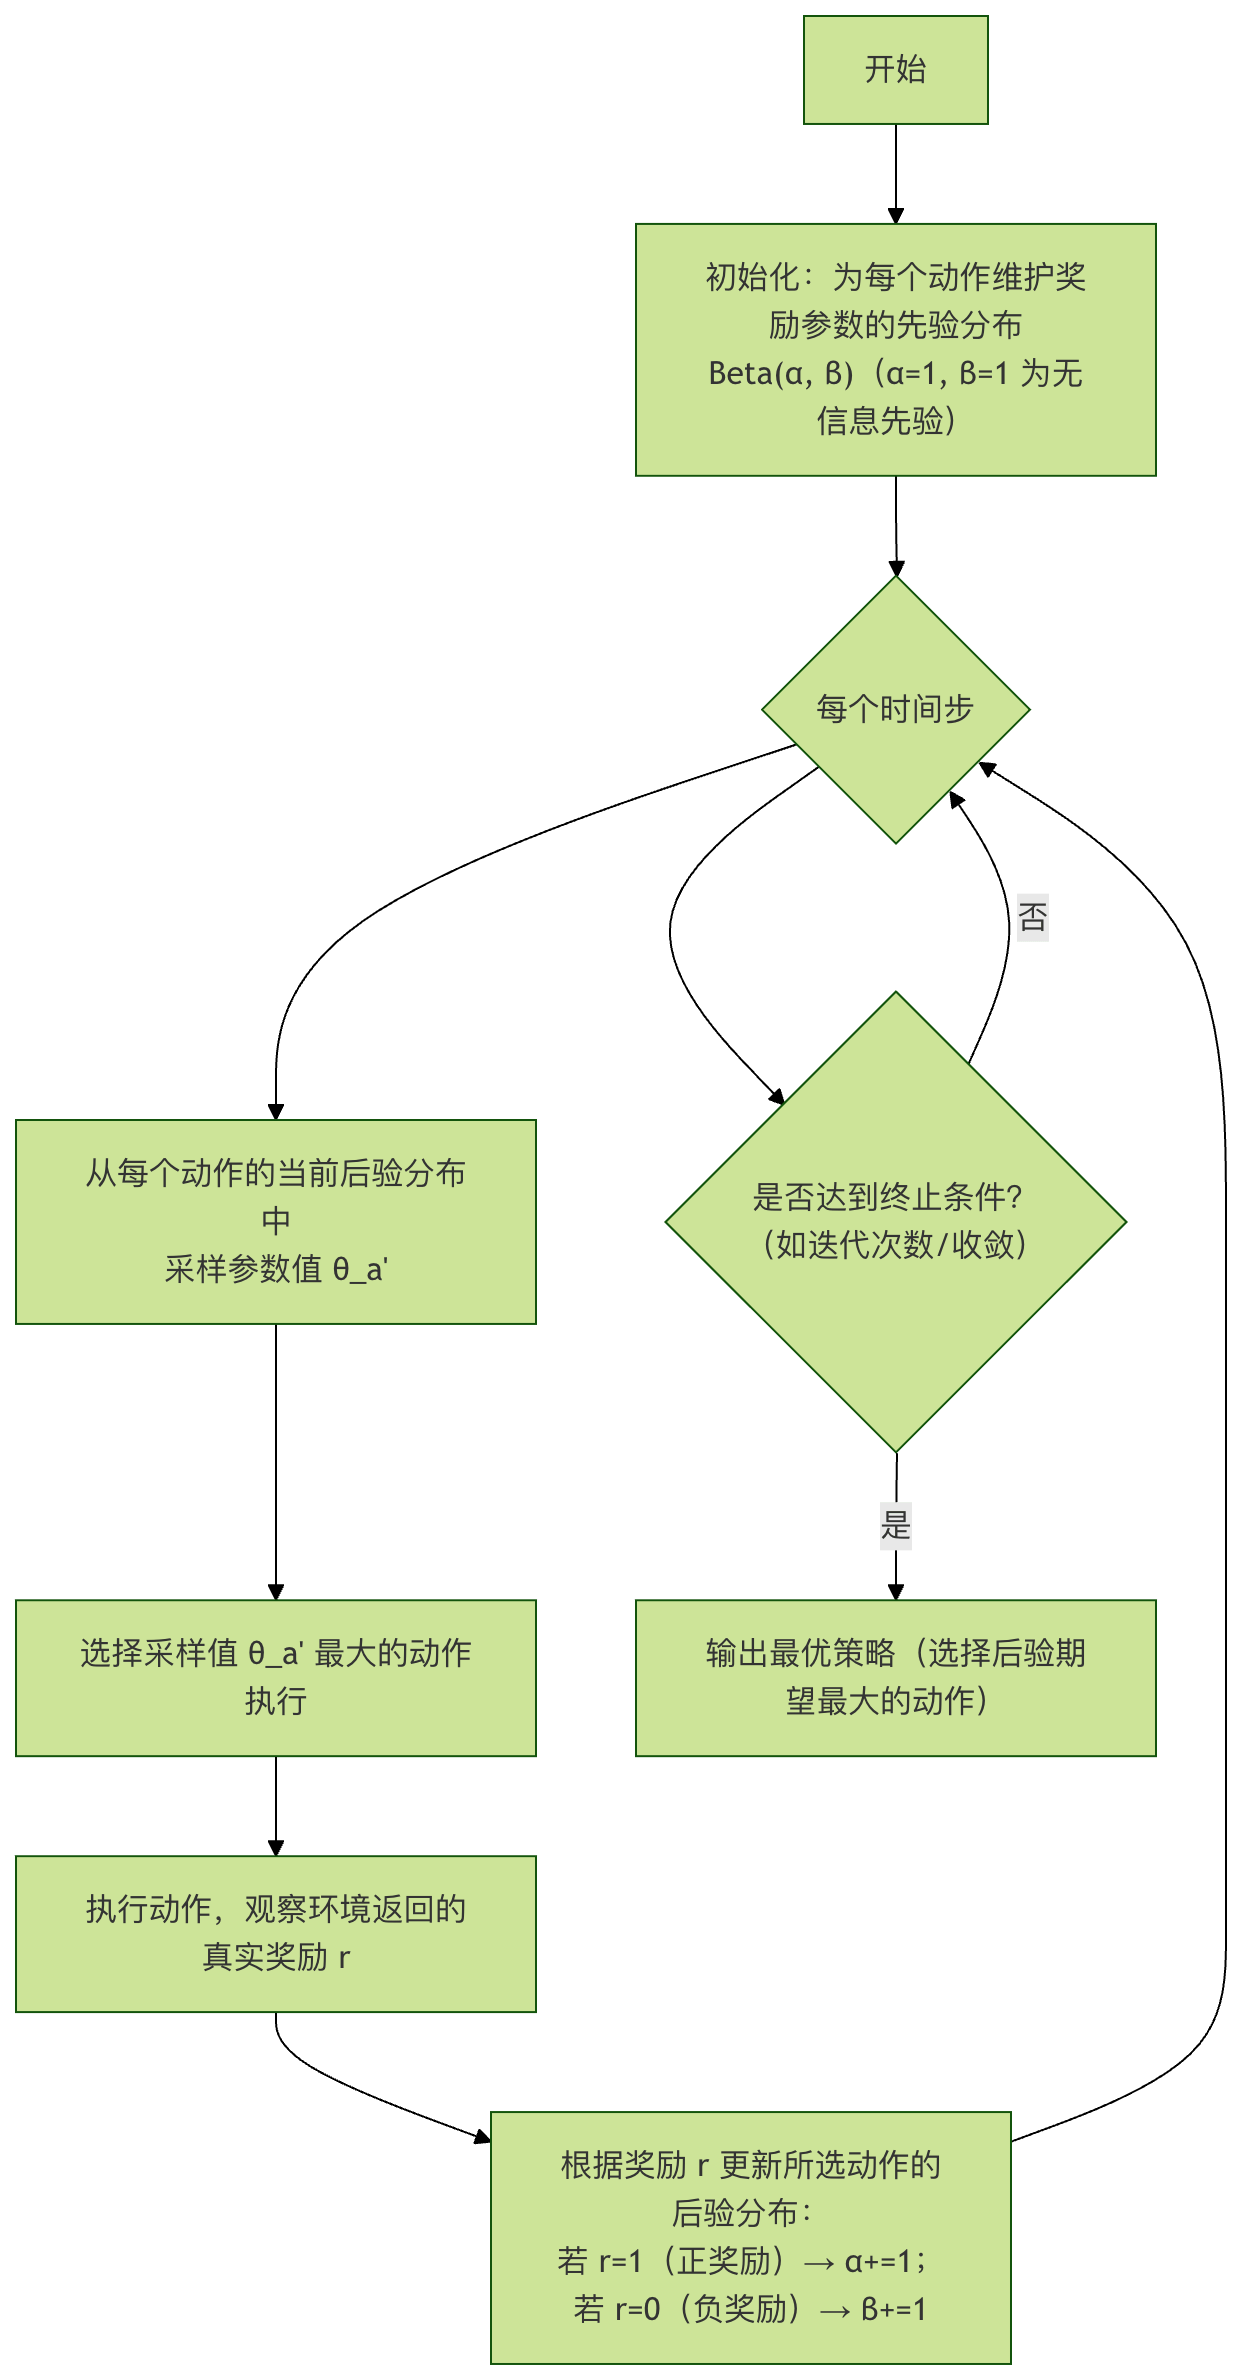

**过程说明:**
- 1. 初始化: 为每个动作 a 假设其获得奖励的概率 θ_a 服从 Beta(α=1, β=1) 分布，这是一个均匀先验。
- 2. 采样：每一步，从每个动作 a 的当前 Beta(α_a, β_a) 分布中独立采样一个值 θ_a'。
- 3. 选择动作：选择采样值 θ_a' 最大的动作 a_t 执行。
- 4. 更新：根据执行动作 a_t 后获得的奖励 r_t 更新该动作的 Beta 分布参数：
  - 如果 r_t = 1（成功），则 α_{a_t} = α_{a_t} + 1
  - 如果 r_t = 0（失败），则 β_{a_t} = β_{a_t} + 1

优点 : 汤姆森采样能够自然地平衡探索与开采，尤其在奖励分布未知或复杂的情况下表现出色。它通过概率性选择动作，能够更有效地利用历史数据进行决策。

缺点 : 实现和理解相对复杂，尤其是在奖励分布不服从简单的参数化形式时。对于某些环境，可能需要更多的计算资源来维护和更新后验分布。

In [24]:
class TS:
    def __init__(self, n_actions):
        self.n_actions = n_actions
        self.successes = np.zeros(n_actions)  # 每个动作的成功次数
        self.failures = np.zeros(n_actions)   # 每个动作的失败次数

    def select_action(self):
        # 对每个动作采样一个Beta分布的值
        beta_samples = np.random.beta(self.successes + 1, self.failures + 1)
        action = np.argmax(beta_samples)  # 选择Beta分布值最大的动作
        return action
    
    def update(self, action, reward):
        # 更新成功和失败的计数
        if reward == 1:
            self.successes[action] += 1
        else:
            self.failures[action] += 1

# 模拟一个多臂老虎机问题 , 每个臂的真实奖励概率不同
true_means = [0.1 , 0.5 , 0.9]
n_actions = len(true_means)
bandit = TS(n_actions)
total_reward = 0
for step in range(1000):
    action = bandit.select_action()  # 根据TS策略选择动作
    reward = 1 if np.random.random() < true_means[action] else 0  # 模拟奖励
    bandit.update(action, reward)  # 更新TS算法的内部状态
    total_reward += reward

print(f"Total reward: {total_reward}")  # 输出总奖励
print(f"Successes: {bandit.successes}")  # 输出每个动作的成功次数
print(f"Failures: {bandit.failures}")    # 输出每个动作的失败次数

Total reward: 868
Successes: [  1.  10. 857.]
Failures: [  4.   8. 120.]
